# Linkage Algorithm Benchmark on Synthetic BOAMP v0.4

This notebook benchmarks four linkage algorithms on the current synthetic benchmark:
current weighted composite, Fellegi-Sunter/Splink-style log-odds, logistic regression,
and gradient boosting.

## Context & Methods

The benchmark uses the current `v0_4_population_alias_revision` synthetic data. All
algorithms receive the same production candidate pairs. Two evaluation views are shown:

- **Fixed-candidate**: recall denominator is only true links that survived candidate generation.
- **End-to-end**: recall denominator is all in-scope true links, so candidate-generation misses
  count against the algorithm stack.

The supervised models are trained only on central scenario worlds `001`-`004`; thresholds are
selected on central worlds `005`-`006`; the reported evaluation uses worlds `007`-`010` for
all five production scenarios.

### Key Assumptions

This is a synthetic-truth benchmark, not a real-BOAMP ground-truth claim. The candidate generator
is shared across algorithms so the comparison isolates scoring/ranking and thresholding after
production blocking. Because the generator created the labels, all results should be interpreted
with the mechanical-bias caveats from the benchmark readiness report.

## Setup

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src" / "boamp").exists():
            return candidate
    raise RuntimeError("Could not find project root containing src/boamp")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from boamp.config import load_config
from boamp.synthetic.validation_framework.difficulty import (
    FS_ACCEPT_LOG_ODDS,
    FS_AGREEMENT_THRESHOLDS,
    FS_M_PROBABILITIES,
    FS_U_PROBABILITIES,
    _generate_candidates,
    _pair_key_set,
    _pair_scores,
    _unordered,
    scoped_sources,
    true_match_pairs,
)
from boamp.synthetic.validation_framework.loaders import load_benchmark_data

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#2f3437",
    "text.color": "#2f3437",
})

## Parameters

In [2]:
BENCHMARK_VERSION = "v0_4_population_alias_revision"
SCENARIOS = ["central_provisional", "easier", "moderate", "difficult", "stress"]
FIT_SCENARIO = "central_provisional"
FIT_WORLDS = ["001", "002", "003", "004"]
CALIBRATION_WORLDS = ["005", "006"]
EVALUATION_WORLDS = ["007", "008", "009", "010"]
CORRUPTION_FOR_WORLD = {world: world for world in [f"{i:03d}" for i in range(1, 11)]}

OUTPUT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "synthetic_benchmark"
    / BENCHMARK_VERSION
    / "linkage_algorithm_benchmark"
)
FIGURE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "synthetic_benchmark"
    / BENCHMARK_VERSION
    / "linkage_algorithm_benchmark"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config(PROJECT_ROOT)
PRODUCTION_COMPOSITE_THRESHOLD = float(getattr(cfg.pipeline.thresholds, cfg.pipeline.thresholds.primary))
RANDOM_SEED = int(cfg.pipeline.run.random_seed)

print("Benchmark:", BENCHMARK_VERSION)
print("Production composite threshold:", round(PRODUCTION_COMPOSITE_THRESHOLD, 4))
print("Fit worlds:", FIT_SCENARIO, FIT_WORLDS)
print("Calibration worlds:", FIT_SCENARIO, CALIBRATION_WORLDS)
print("Evaluation scenarios/worlds:", SCENARIOS, EVALUATION_WORLDS)

Benchmark: v0_4_population_alias_revision
Production composite threshold: 0.3432
Fit worlds: central_provisional ['001', '002', '003', '004']
Calibration worlds: central_provisional ['005', '006']
Evaluation scenarios/worlds: ['central_provisional', 'easier', 'moderate', 'difficult', 'stress'] ['007', '008', '009', '010']


## Data

In [3]:
def fellegi_sunter_log_odds(frame: pd.DataFrame) -> pd.Series:
    score = np.zeros(len(frame), dtype=float)
    for field, threshold in FS_AGREEMENT_THRESHOLDS.items():
        values = pd.to_numeric(frame[field], errors="coerce")
        agree = values.ge(threshold).fillna(False).to_numpy()
        m = FS_M_PROBABILITIES[field]
        u = FS_U_PROBABILITIES[field]
        score += np.where(agree, np.log(m / u), np.log((1 - m) / (1 - u)))
    return pd.Series(score, index=frame.index)


def add_source_candidate_context(scored: pd.DataFrame, scoped: pd.DataFrame) -> pd.DataFrame:
    attrs = scoped.copy()
    attrs["notice_id"] = attrs["notice_id"].astype(str)
    attrs["publication_year"] = pd.to_datetime(attrs["publication_date"]).dt.year
    context_cols = [
        "notice_id",
        "schema_family",
        "notice_type_normalized",
        "publication_year",
        "buyer_key_type",
        "code_departement",
        "cpv_clean",
        "cpv_division",
        "declared_duration_months",
        "dur_was_imputed",
    ]
    available = [c for c in context_cols if c in attrs.columns]
    source_context = attrs[available].rename(
        columns={c: f"source_{c}" for c in available if c != "notice_id"}
    )
    candidate_context = attrs[available].rename(
        columns={c: f"candidate_{c}" for c in available if c != "notice_id"}
    )
    out = scored.merge(
        source_context,
        left_on="source_notice_id",
        right_on="notice_id",
        how="left",
    ).drop(columns=["notice_id"], errors="ignore")
    out = out.merge(
        candidate_context,
        left_on="candidate_notice_id",
        right_on="notice_id",
        how="left",
    ).drop(columns=["notice_id"], errors="ignore")
    out["source_cpv_missing"] = out["source_cpv_clean"].isna()
    out["source_duration_missing"] = out["source_declared_duration_months"].isna()
    out["candidate_count_bin"] = pd.cut(
        out["n_candidates_for_source"].fillna(0),
        bins=[-0.1, 0, 1, 3, 7, 15, np.inf],
        labels=["0", "1", "2-3", "4-7", "8-15", "16+"],
    )
    return out


def load_world_frame(scenario: str, world: str) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    corruption = CORRUPTION_FOR_WORLD[world]
    data = load_benchmark_data(PROJECT_ROOT, BENCHMARK_VERSION, scenario, world, corruption)
    scoped = scoped_sources(data)
    scoped_ids = set(scoped["notice_id"].astype(str))
    truth = true_match_pairs(data)
    truth_in_scope = truth.loc[
        truth["notice_a"].astype(str).isin(scoped_ids)
        & truth["notice_b"].astype(str).isin(scoped_ids)
    ].copy()
    truth_set = _pair_key_set(truth_in_scope, "notice_a", "notice_b")
    pairs = _generate_candidates(scoped, cfg, window=None)
    scored = _pair_scores(pairs, truth_set)
    scored = add_source_candidate_context(scored, scoped)
    scored["scenario"] = scenario
    scored["world"] = world
    scored["corruption"] = corruption
    scored["pair_key"] = [
        _unordered(a, b)
        for a, b in zip(scored["source_notice_id"], scored["candidate_notice_id"])
    ]
    scored["global_pair_key"] = [
        f"{scenario}|{world}|{a}|{b}"
        for a, b in scored["pair_key"]
    ]
    scored["fs_log_odds"] = fellegi_sunter_log_odds(scored)
    truth_global_set = {
        f"{scenario}|{world}|{a}|{b}"
        for a, b in truth_set
    }
    candidate_global_set = set(scored["global_pair_key"])
    reachable_truth = candidate_global_set & truth_global_set

    scoped_attrs = scoped.copy()
    scoped_attrs["notice_id"] = scoped_attrs["notice_id"].astype(str)
    scoped_attrs["publication_year"] = pd.to_datetime(scoped_attrs["publication_date"]).dt.year
    source_attr_cols = [
        "notice_id",
        "buyer_key_type",
        "schema_family",
        "publication_year",
        "code_departement",
        "cpv_clean",
        "cpv_division",
        "declared_duration_months",
        "dur_was_imputed",
    ]
    source_attrs = scoped_attrs[[c for c in source_attr_cols if c in scoped_attrs.columns]]
    truth_context = truth_in_scope.merge(
        source_attrs.add_prefix("source_"),
        left_on="notice_a",
        right_on="source_notice_id",
        how="left",
    )
    truth_context["scenario"] = scenario
    truth_context["world"] = world
    truth_context["corruption"] = corruption
    truth_context["pair_key"] = [
        _unordered(a, b)
        for a, b in zip(truth_context["notice_a"], truth_context["notice_b"])
    ]
    truth_context["global_pair_key"] = [
        f"{scenario}|{world}|{a}|{b}"
        for a, b in truth_context["pair_key"]
    ]
    truth_context["reachable_by_production_candidates"] = truth_context["global_pair_key"].isin(reachable_truth)
    source_candidate_counts = (
        scored.groupby("source_notice_id")["candidate_notice_id"]
        .size()
        .rename("n_candidates_for_source")
        .reset_index()
    )
    truth_context = truth_context.merge(
        source_candidate_counts,
        left_on="notice_a",
        right_on="source_notice_id",
        how="left",
        suffixes=("", "_from_candidates"),
    ).drop(columns=["source_notice_id_from_candidates"], errors="ignore")
    truth_context["n_candidates_for_source"] = truth_context["n_candidates_for_source"].fillna(0)
    truth_context["candidate_count_bin"] = pd.cut(
        truth_context["n_candidates_for_source"],
        bins=[-0.1, 0, 1, 3, 7, 15, np.inf],
        labels=["0", "1", "2-3", "4-7", "8-15", "16+"],
    )
    truth_context["source_cpv_missing"] = truth_context["source_cpv_clean"].isna()
    truth_context["source_duration_missing"] = truth_context["source_declared_duration_months"].isna()

    metadata = {
        "scenario": scenario,
        "world": world,
        "corruption": corruption,
        "n_scoped_sources": int(len(scoped)),
        "n_candidate_pairs": int(len(scored)),
        "n_truth_in_scope": int(len(truth_set)),
        "n_reachable_truth": int(len(reachable_truth)),
        "blocking_recall": float(len(reachable_truth) / len(truth_set)) if truth_set else np.nan,
    }
    return scored, truth_context, metadata


def collect_frames(scenarios: list[str], worlds: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    pair_frames = []
    truth_frames = []
    metadata_rows = []
    for scenario in scenarios:
        for world in worlds:
            scored, truth_context, metadata = load_world_frame(scenario, world)
            pair_frames.append(scored)
            truth_frames.append(truth_context)
            metadata_rows.append(metadata)
            print(
                f"{scenario} world {world}: "
                f"{metadata['n_candidate_pairs']:,} pairs; "
                f"{metadata['n_truth_in_scope']:,} truth; "
                f"blocking recall {metadata['blocking_recall']:.3f}"
            )
    return (
        pd.concat(pair_frames, ignore_index=True),
        pd.concat(truth_frames, ignore_index=True),
        pd.DataFrame(metadata_rows),
    )

In [4]:
fit_pairs, fit_truth, fit_metadata = collect_frames([FIT_SCENARIO], FIT_WORLDS)
calibration_pairs, calibration_truth, calibration_metadata = collect_frames([FIT_SCENARIO], CALIBRATION_WORLDS)
evaluation_pairs, evaluation_truth, evaluation_metadata = collect_frames(SCENARIOS, EVALUATION_WORLDS)

for name, frame in [
    ("fit_pairs", fit_pairs),
    ("calibration_pairs", calibration_pairs),
    ("evaluation_pairs", evaluation_pairs),
]:
    print(f"{name}: {len(frame):,} candidate rows; true pair rate={frame['is_true_match'].mean():.4f}")

metadata_all = pd.concat(
    [
        fit_metadata.assign(split="fit"),
        calibration_metadata.assign(split="calibration"),
        evaluation_metadata.assign(split="evaluation"),
    ],
    ignore_index=True,
)
metadata_all.to_csv(OUTPUT_DIR / "world_candidate_metadata.csv", index=False)
metadata_all

central_provisional world 001: 8,380 pairs; 1,262 truth; blocking recall 0.348


central_provisional world 002: 13,496 pairs; 1,557 truth; blocking recall 0.355


central_provisional world 003: 17,594 pairs; 1,537 truth; blocking recall 0.354


central_provisional world 004: 9,480 pairs; 1,316 truth; blocking recall 0.343


central_provisional world 005: 9,249 pairs; 1,500 truth; blocking recall 0.339


...

stress world 008: 94,459 pairs; 1,006 truth; blocking recall 0.160


stress world 009: 89,085 pairs; 972 truth; blocking recall 0.166


stress world 010: 72,819 pairs; 766 truth; blocking recall 0.188


fit_pairs: 48,950 candidate rows; true pair rate=0.0406
calibration_pairs: 16,174 candidate rows; true pair rate=0.0605
evaluation_pairs: 879,179 candidate rows; true pair rate=0.0118


,scenario,world,corruption,n_scoped_sources,n_candidate_pairs,n_truth_in_scope,n_reachable_truth,blocking_recall,split
0,central_provisional,001,001,3107,8380,1262,439,0.347861,fit
1,central_provisional,002,002,3678,13496,1557,553,0.355170,fit
2,central_provisional,003,003,3732,17594,1537,544,0.353936,fit
3,central_provisional,004,004,3189,9480,1316,452,0.343465,fit
4,central_provisional,005,005,3524,9249,1500,508,0.338667,calibration
5,central_provisional,006,006,3260,6925,1352,471,0.348373,calibration
6,central_provisional,007,007,3487,20298,1469,518,0.352621,evaluation
7,central_provisional,008,008,3994,28181,1712,518,0.302570,evaluation
8,central_provisional,009,009,3693,11623,1552,507,0.326675,evaluation
9,central_provisional,010,010,4105,20699,1755,623,0.354986,evaluation


## Model Training

In [5]:
NUMERIC_FEATURES = [
    "s_text",
    "s_cpv",
    "s_time",
    "s_buyer",
    "gap_months",
    "abs_gap_to_expected_end",
    "n_candidates_for_source",
    "source_publication_year",
]
BINARY_FEATURES = [
    "cpv_missing",
    "cpv_generic_flag",
    "source_cpv_missing",
    "source_duration_missing",
]
CATEGORICAL_FEATURES = [
    "buyer_key_type",
    "source_schema_family",
    "source_cpv_division",
]
FEATURE_COLUMNS = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

def make_feature_frame(frame: pd.DataFrame) -> pd.DataFrame:
    features = frame[FEATURE_COLUMNS].copy()
    for col in BINARY_FEATURES:
        features[col] = features[col].astype(float)
    return features

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

logistic_model = Pipeline(
    steps=[
        (
            "preprocess",
            ColumnTransformer(
                transformers=[
                    (
                        "num",
                        Pipeline(
                            steps=[
                                ("imputer", SimpleImputer(strategy="median")),
                                ("scaler", StandardScaler()),
                            ]
                        ),
                        NUMERIC_FEATURES + BINARY_FEATURES,
                    ),
                    (
                        "cat",
                        Pipeline(
                            steps=[
                                ("imputer", SimpleImputer(strategy="most_frequent")),
                                ("onehot", one_hot),
                            ]
                        ),
                        CATEGORICAL_FEATURES,
                    ),
                ]
            ),
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

gradient_boosting_model = Pipeline(
    steps=[
        (
            "preprocess",
            ColumnTransformer(
                transformers=[
                    (
                        "num",
                        Pipeline(
                            steps=[
                                ("imputer", SimpleImputer(strategy="median")),
                            ]
                        ),
                        NUMERIC_FEATURES + BINARY_FEATURES,
                    ),
                    (
                        "cat",
                        Pipeline(
                            steps=[
                                ("imputer", SimpleImputer(strategy="most_frequent")),
                                ("onehot", one_hot),
                            ]
                        ),
                        CATEGORICAL_FEATURES,
                    ),
                ]
            ),
        ),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=160,
                learning_rate=0.045,
                max_depth=3,
                subsample=0.8,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

X_fit = make_feature_frame(fit_pairs)
y_fit = fit_pairs["is_true_match"].astype(int)
logistic_model.fit(X_fit, y_fit)
gradient_boosting_model.fit(X_fit, y_fit)

fit_pairs = fit_pairs.copy()
calibration_pairs = calibration_pairs.copy()
evaluation_pairs = evaluation_pairs.copy()
for frame_name, frame in [
    ("fit", fit_pairs),
    ("calibration", calibration_pairs),
    ("evaluation", evaluation_pairs),
]:
    X = make_feature_frame(frame)
    frame["logistic_score"] = logistic_model.predict_proba(X)[:, 1]
    frame["gradient_boosting_score"] = gradient_boosting_model.predict_proba(X)[:, 1]
    print(
        frame_name,
        "logistic AP",
        round(average_precision_score(frame["is_true_match"], frame["logistic_score"]), 3),
        "GB AP",
        round(average_precision_score(frame["is_true_match"], frame["gradient_boosting_score"]), 3),
    )

evaluation_pairs[
    [
        "scenario",
        "world",
        "source_notice_id",
        "candidate_notice_id",
        "is_true_match",
        "composite_score",
        "fs_log_odds",
        "logistic_score",
        "gradient_boosting_score",
    ]
].head()

fit logistic AP 0.657 GB AP 0.851
calibration logistic AP 0.695 GB AP 0.868


evaluation logistic AP 0.294 GB AP 0.766


,scenario,world,source_notice_id,candidate_notice_id,is_true_match,composite_score,fs_log_odds,logistic_score,gradient_boosting_score
0,central_provisional,007,NOTICE-00000012,NOTICE-00000042,False,0.356312,-2.082042,0.302790,0.128727
1,central_provisional,007,NOTICE-00000020,NOTICE-00000068,False,0.720892,0.402864,0.975570,0.145477
2,central_provisional,007,NOTICE-00000025,NOTICE-00000055,False,0.323855,-2.082042,0.727715,0.114999
3,central_provisional,007,NOTICE-00000025,NOTICE-00000054,False,0.184896,-3.106547,0.023091,0.004764
4,central_provisional,007,NOTICE-00000032,NOTICE-00000018,False,0.331129,-0.621640,0.040972,0.026515


## Link Selection

In [6]:
ALGORITHM_SPECS = {
    "current_weighted_composite": {
        "score_col": "composite_score",
        "threshold": PRODUCTION_COMPOSITE_THRESHOLD,
        "threshold_source": "production primary threshold",
    },
    "fellegi_sunter_style": {
        "score_col": "fs_log_odds",
        "threshold": FS_ACCEPT_LOG_ODDS,
        "threshold_source": "frozen zero log-odds threshold",
    },
    "logistic_regression": {
        "score_col": "logistic_score",
        "threshold": None,
        "threshold_source": "calibration F1 maximum",
    },
    "gradient_boosting": {
        "score_col": "gradient_boosting_score",
        "threshold": None,
        "threshold_source": "calibration F1 maximum",
    },
}

def select_top_links(frame: pd.DataFrame, score_col: str, threshold: float) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()
    ordered = frame.sort_values(
        ["scenario", "world", "source_notice_id", score_col, "candidate_date"],
        ascending=[True, True, True, False, True],
    )
    top = ordered.groupby(["scenario", "world", "source_notice_id"], as_index=False).head(1).copy()
    return top.loc[top[score_col].ge(threshold)].copy()

def metrics_for_predictions(
    predictions: pd.DataFrame,
    pairs: pd.DataFrame,
    truth_context: pd.DataFrame,
    score_col: str,
    algorithm: str,
) -> dict:
    pred_set = set(predictions["global_pair_key"])
    truth_set = set(truth_context["global_pair_key"])
    reachable_set = set(
        truth_context.loc[
            truth_context["reachable_by_production_candidates"], "global_pair_key"
        ]
    )
    tp = len(pred_set & truth_set)
    precision = tp / len(pred_set) if pred_set else np.nan
    recall_end_to_end = tp / len(truth_set) if truth_set else np.nan
    recall_fixed_candidate = tp / len(reachable_set) if reachable_set else np.nan
    f1_end_to_end = (
        2 * precision * recall_end_to_end / (precision + recall_end_to_end)
        if precision and recall_end_to_end
        else 0.0
    )
    f1_fixed_candidate = (
        2 * precision * recall_fixed_candidate / (precision + recall_fixed_candidate)
        if precision and recall_fixed_candidate
        else 0.0
    )
    top_ranked = (
        pairs.sort_values(
            ["scenario", "world", "source_notice_id", score_col, "candidate_date"],
            ascending=[True, True, True, False, True],
        )
        .groupby(["scenario", "world", "source_notice_id"], as_index=False)
        .head(1)
    )
    reachable_sources = set(
        truth_context.loc[
            truth_context["reachable_by_production_candidates"], ["scenario", "world", "notice_a"]
        ].itertuples(index=False, name=None)
    )
    top1_truth = set(
        top_ranked.loc[top_ranked["is_true_match"], ["scenario", "world", "source_notice_id"]]
        .itertuples(index=False, name=None)
    )
    top1_accuracy_when_reachable = (
        len(reachable_sources & top1_truth) / len(reachable_sources)
        if reachable_sources
        else np.nan
    )
    try:
        roc_auc = roc_auc_score(pairs["is_true_match"].astype(int), pairs[score_col])
    except ValueError:
        roc_auc = np.nan
    try:
        average_precision = average_precision_score(
            pairs["is_true_match"].astype(int), pairs[score_col]
        )
    except ValueError:
        average_precision = np.nan
    return {
        "algorithm": algorithm,
        "score_col": score_col,
        "n_pairs": int(len(pairs)),
        "n_truth_in_scope": int(len(truth_set)),
        "n_reachable_truth": int(len(reachable_set)),
        "n_predicted_pairs": int(len(pred_set)),
        "true_positive_pairs": int(tp),
        "pair_precision": precision,
        "pair_recall_fixed_candidate": recall_fixed_candidate,
        "pair_recall_end_to_end": recall_end_to_end,
        "pair_f1_fixed_candidate": f1_fixed_candidate,
        "pair_f1_end_to_end": f1_end_to_end,
        "top1_accuracy_when_reachable": top1_accuracy_when_reachable,
        "roc_auc_candidate_pairs": roc_auc,
        "average_precision_candidate_pairs": average_precision,
    }

def tune_threshold_on_calibration(score_col: str) -> float:
    top_scores = (
        calibration_pairs.sort_values(
            ["scenario", "world", "source_notice_id", score_col, "candidate_date"],
            ascending=[True, True, True, False, True],
        )
        .groupby(["scenario", "world", "source_notice_id"], as_index=False)
        .head(1)
    )
    candidates = np.unique(np.quantile(top_scores[score_col].dropna(), np.linspace(0.02, 0.98, 97)))
    best_threshold = float(candidates[0])
    best_f1 = -1.0
    for threshold in candidates:
        pred = select_top_links(calibration_pairs, score_col, float(threshold))
        row = metrics_for_predictions(
            pred,
            calibration_pairs,
            calibration_truth,
            score_col,
            f"calibration_{score_col}",
        )
        if row["pair_f1_end_to_end"] > best_f1:
            best_f1 = row["pair_f1_end_to_end"]
            best_threshold = float(threshold)
    return best_threshold

for name in ["logistic_regression", "gradient_boosting"]:
    score_col = ALGORITHM_SPECS[name]["score_col"]
    ALGORITHM_SPECS[name]["threshold"] = tune_threshold_on_calibration(score_col)

threshold_rows = []
for algorithm, spec in ALGORITHM_SPECS.items():
    threshold_rows.append(
        {
            "algorithm": algorithm,
            "score_col": spec["score_col"],
            "threshold": spec["threshold"],
            "threshold_source": spec["threshold_source"],
        }
    )
threshold_table = pd.DataFrame(threshold_rows)
threshold_table.to_csv(OUTPUT_DIR / "algorithm_thresholds.csv", index=False)
threshold_table

,algorithm,score_col,threshold,threshold_source
0,current_weighted_composite,composite_score,0.343167,production primary threshold
1,fellegi_sunter_style,fs_log_odds,0.000000,frozen zero log-odds threshold
2,logistic_regression,logistic_score,0.745678,calibration F1 maximum
3,gradient_boosting,gradient_boosting_score,0.230964,calibration F1 maximum


## Results

In [7]:
prediction_frames = []
metric_rows = []
per_world_rows = []

for algorithm, spec in ALGORITHM_SPECS.items():
    score_col = spec["score_col"]
    threshold = float(spec["threshold"])
    predictions = select_top_links(evaluation_pairs, score_col, threshold)
    predictions["algorithm"] = algorithm
    predictions["score_col"] = score_col
    predictions["threshold"] = threshold
    prediction_frames.append(predictions)
    metric_rows.append(
        metrics_for_predictions(
            predictions, evaluation_pairs, evaluation_truth, score_col, algorithm
        )
    )
    for (scenario, world), pair_sub in evaluation_pairs.groupby(["scenario", "world"]):
        truth_sub = evaluation_truth.loc[
            evaluation_truth["scenario"].eq(scenario) & evaluation_truth["world"].eq(world)
        ]
        pred_sub = predictions.loc[
            predictions["scenario"].eq(scenario) & predictions["world"].eq(world)
        ]
        row = metrics_for_predictions(pred_sub, pair_sub, truth_sub, score_col, algorithm)
        row["scenario"] = scenario
        row["world"] = world
        per_world_rows.append(row)

predictions_all = pd.concat(prediction_frames, ignore_index=True)
summary_metrics = pd.DataFrame(metric_rows).sort_values("pair_f1_end_to_end", ascending=False)
per_world_metrics = pd.DataFrame(per_world_rows)
summary_metrics.to_csv(OUTPUT_DIR / "summary_metrics.csv", index=False)
per_world_metrics.to_csv(OUTPUT_DIR / "per_world_metrics.csv", index=False)
predictions_all.to_parquet(OUTPUT_DIR / "predicted_links.parquet", index=False)

summary_metrics[
    [
        "algorithm",
        "n_predicted_pairs",
        "true_positive_pairs",
        "pair_precision",
        "pair_recall_fixed_candidate",
        "pair_recall_end_to_end",
        "pair_f1_fixed_candidate",
        "pair_f1_end_to_end",
        "top1_accuracy_when_reachable",
        "average_precision_candidate_pairs",
    ]
].style.format({
    "pair_precision": "{:.3f}",
    "pair_recall_fixed_candidate": "{:.3f}",
    "pair_recall_end_to_end": "{:.3f}",
    "pair_f1_fixed_candidate": "{:.3f}",
    "pair_f1_end_to_end": "{:.3f}",
    "top1_accuracy_when_reachable": "{:.3f}",
    "average_precision_candidate_pairs": "{:.3f}",
})

,algorithm,n_predicted_pairs,true_positive_pairs,pair_precision,pair_recall_fixed_candidate,pair_recall_end_to_end,pair_f1_fixed_candidate,pair_f1_end_to_end,top1_accuracy_when_reachable,average_precision_candidate_pairs
3,gradient_boosting,10610,7624,0.719,0.738,0.235,0.728,0.354,0.865,0.766
2,logistic_regression,22706,7704,0.339,0.746,0.238,0.466,0.280,0.827,0.294
0,current_weighted_composite,56103,7288,0.130,0.705,0.225,0.219,0.165,0.754,0.090
1,fellegi_sunter_style,41909,4752,0.113,0.460,0.147,0.182,0.128,0.691,0.157


## tl;dr

In [8]:
best = summary_metrics.sort_values("pair_f1_end_to_end", ascending=False).iloc[0]
composite = summary_metrics.loc[
    summary_metrics["algorithm"].eq("current_weighted_composite")
].iloc[0]
blocking = evaluation_metadata["blocking_recall"].mean()
display(
    Markdown(
        f'''
        - Executed benchmark scope: {len(SCENARIOS)} scenarios x {len(EVALUATION_WORLDS)} held-out worlds
          ({len(evaluation_pairs):,} candidate pairs; {evaluation_truth['global_pair_key'].nunique():,} in-scope truth pairs).
        - Mean production blocking recall across evaluation worlds is **{blocking:.3f}**, so end-to-end recall is
          materially lower than fixed-candidate recall for every scoring algorithm.
        - Best end-to-end pair-F1 in this run is **{best['algorithm']}** at **{best['pair_f1_end_to_end']:.3f}**.
        - Current weighted composite end-to-end pair-F1 is **{composite['pair_f1_end_to_end']:.3f}** with
          precision **{composite['pair_precision']:.3f}** and end-to-end recall **{composite['pair_recall_end_to_end']:.3f}**.
        - Treat these as synthetic-benchmark results only. They are useful for comparing algorithm behavior under known truth,
          but not sufficient to claim real BOAMP linkage accuracy without manual real labels.
        '''
    )
)


        - Executed benchmark scope: 5 scenarios x 4 held-out worlds
          (879,179 candidate pairs; 32,404 in-scope truth pairs).
        - Mean production blocking recall across evaluation worlds is **0.291**, so end-to-end recall is
          materially lower than fixed-candidate recall for every scoring algorithm.
        - Best end-to-end pair-F1 in this run is **gradient_boosting** at **0.354**.
        - Current weighted composite end-to-end pair-F1 is **0.165** with
          precision **0.130** and end-to-end recall **0.225**.
        - Treat these as synthetic-benchmark results only. They are useful for comparing algorithm behavior under known truth,
          but not sufficient to claim real BOAMP linkage accuracy without manual real labels.
        

### Aggregate Performance

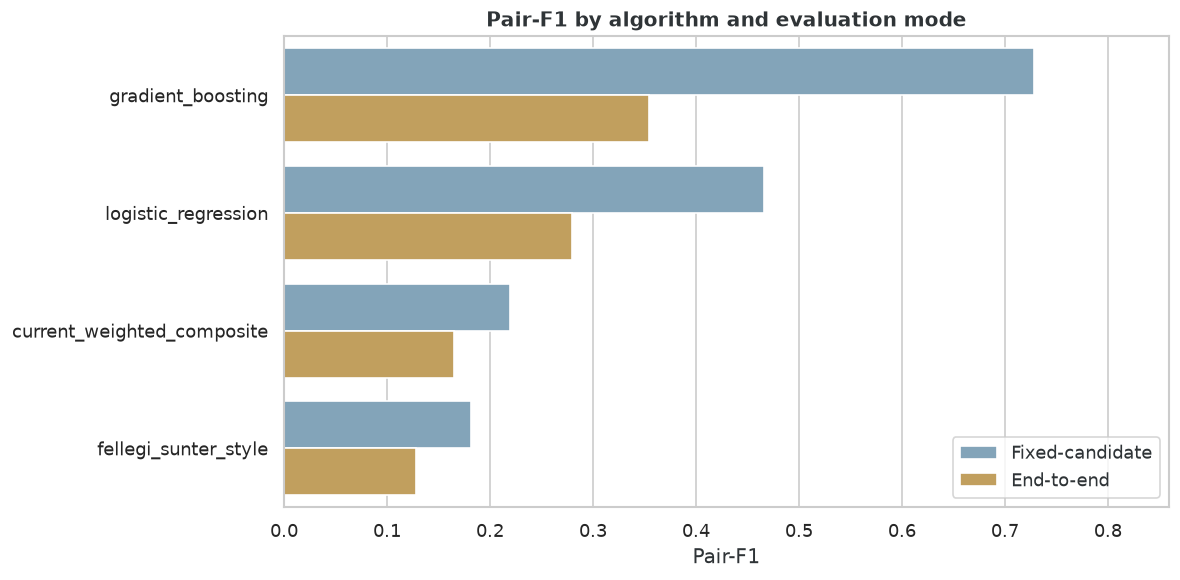

In [9]:
palette = {
    "current_weighted_composite": "#2f6f9f",
    "fellegi_sunter_style": "#b8870b",
    "logistic_regression": "#8a5a99",
    "gradient_boosting": "#4b8b3b",
}

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = summary_metrics.melt(
    id_vars=["algorithm"],
    value_vars=["pair_f1_fixed_candidate", "pair_f1_end_to_end"],
    var_name="evaluation_mode",
    value_name="pair_f1",
)
plot_data["evaluation_mode"] = plot_data["evaluation_mode"].map(
    {
        "pair_f1_fixed_candidate": "Fixed-candidate",
        "pair_f1_end_to_end": "End-to-end",
    }
)
sns.barplot(
    data=plot_data,
    x="pair_f1",
    y="algorithm",
    hue="evaluation_mode",
    ax=ax,
    palette=["#7aa6c2", "#d1a44d"],
)
ax.set_title("Pair-F1 by algorithm and evaluation mode")
ax.set_xlabel("Pair-F1")
ax.set_ylabel("")
ax.set_xlim(0, max(0.05, plot_data["pair_f1"].max() * 1.18))
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pair_f1_by_mode.png", bbox_inches="tight")
plt.show()

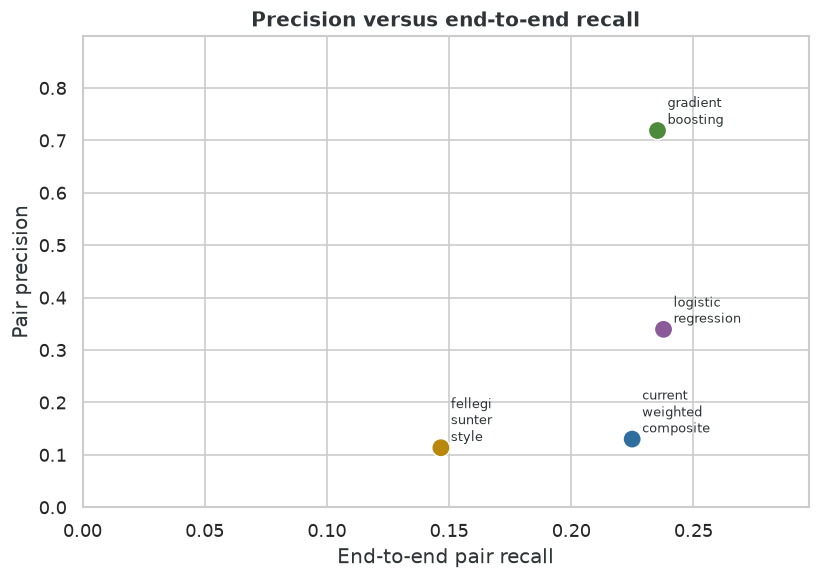

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=summary_metrics,
    x="pair_recall_end_to_end",
    y="pair_precision",
    hue="algorithm",
    s=120,
    palette=palette,
    ax=ax,
)
for row in summary_metrics.itertuples():
    ax.annotate(
        row.algorithm.replace("_", "\n"),
        (row.pair_recall_end_to_end, row.pair_precision),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
    )
ax.set_title("Precision versus end-to-end recall")
ax.set_xlabel("End-to-end pair recall")
ax.set_ylabel("Pair precision")
ax.set_xlim(0, max(0.05, summary_metrics["pair_recall_end_to_end"].max() * 1.25))
ax.set_ylim(0, min(1.0, max(0.1, summary_metrics["pair_precision"].max() * 1.25)))
ax.legend_.remove()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "precision_recall_scatter.png", bbox_inches="tight")
plt.show()

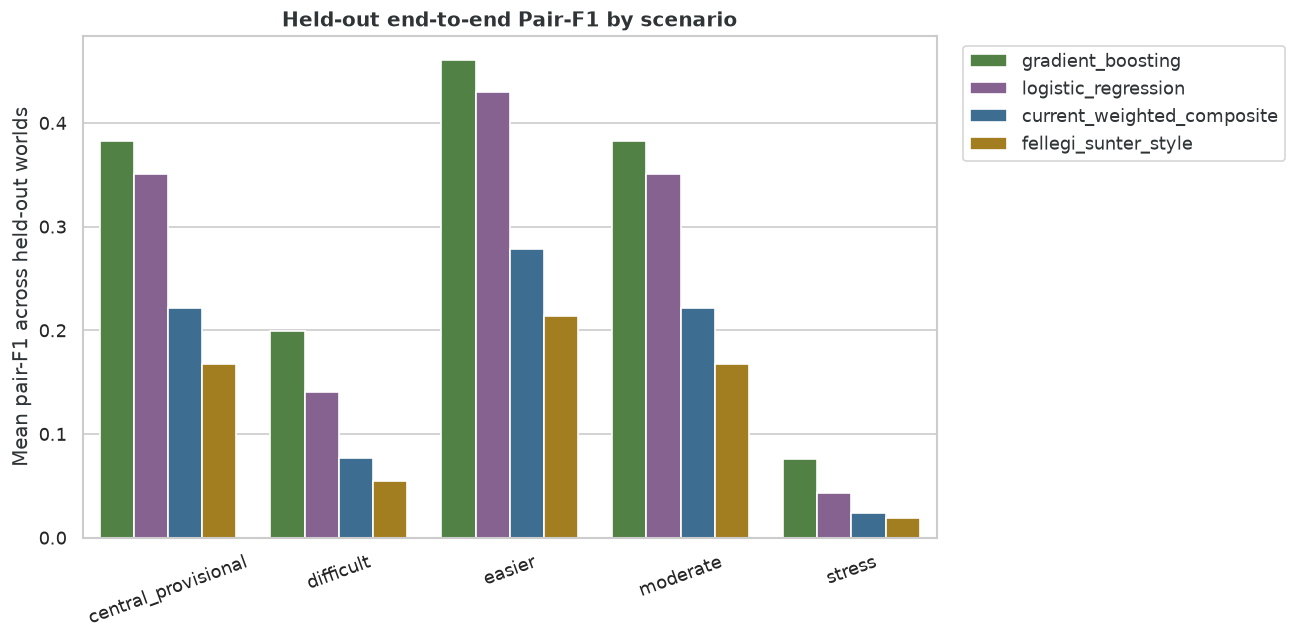

,scenario,algorithm,mean_f1,sd_f1,mean_precision,mean_recall,n_worlds
2,central_provisional,gradient_boosting,0.382123,0.014994,0.770183,0.254339,4
3,central_provisional,logistic_regression,0.350449,0.011278,0.548725,0.257710,4
0,central_provisional,current_weighted_composite,0.221670,0.014324,0.204080,0.243743,4
1,central_provisional,fellegi_sunter_style,0.167788,0.011806,0.180673,0.157827,4
6,difficult,gradient_boosting,0.198757,0.022924,0.475245,0.126328,4
7,difficult,logistic_regression,0.139929,0.020766,0.143257,0.137900,4
4,difficult,current_weighted_composite,0.076581,0.024453,0.053911,0.133125,4
5,difficult,fellegi_sunter_style,0.054785,0.019377,0.042914,0.076700,4
10,easier,gradient_boosting,0.460344,0.028859,0.879255,0.312098,4
11,easier,logistic_regression,0.429259,0.024931,0.715213,0.306883,4


In [11]:
scenario_summary = (
    per_world_metrics.groupby(["scenario", "algorithm"], as_index=False)
    .agg(
        mean_f1=("pair_f1_end_to_end", "mean"),
        sd_f1=("pair_f1_end_to_end", "std"),
        mean_precision=("pair_precision", "mean"),
        mean_recall=("pair_recall_end_to_end", "mean"),
        n_worlds=("world", "nunique"),
    )
    .sort_values(["scenario", "mean_f1"], ascending=[True, False])
)
scenario_summary.to_csv(OUTPUT_DIR / "scenario_summary_metrics.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(
    data=scenario_summary,
    x="scenario",
    y="mean_f1",
    hue="algorithm",
    palette=palette,
    ax=ax,
)
ax.set_title("Held-out end-to-end Pair-F1 by scenario")
ax.set_xlabel("")
ax.set_ylabel("Mean pair-F1 across held-out worlds")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "scenario_pair_f1.png", bbox_inches="tight")
plt.show()

scenario_summary.head(12)

### Score Separability

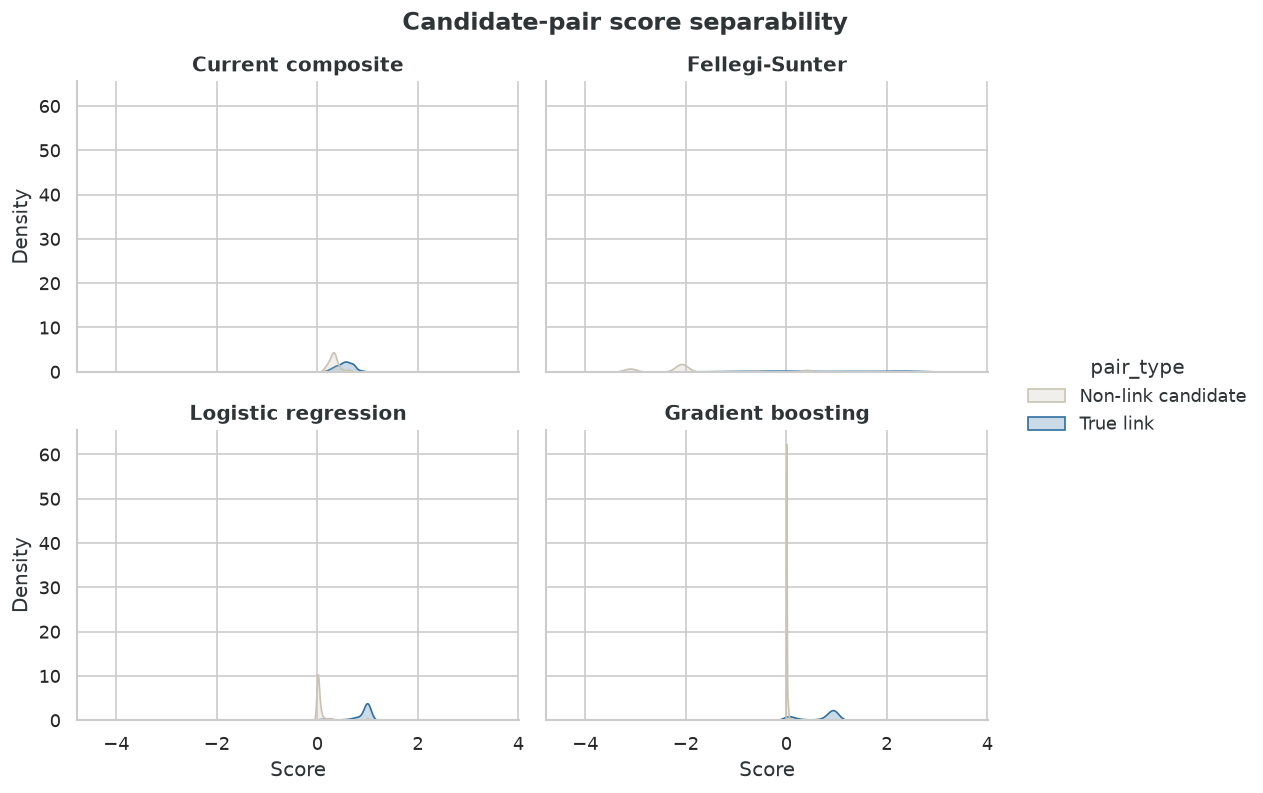

In [12]:
score_long = evaluation_pairs.sample(
    min(60000, len(evaluation_pairs)), random_state=RANDOM_SEED
).melt(
    id_vars=["is_true_match"],
    value_vars=[
        "composite_score",
        "fs_log_odds",
        "logistic_score",
        "gradient_boosting_score",
    ],
    var_name="score",
    value_name="value",
)
score_long["score"] = score_long["score"].map(
    {
        "composite_score": "Current composite",
        "fs_log_odds": "Fellegi-Sunter",
        "logistic_score": "Logistic regression",
        "gradient_boosting_score": "Gradient boosting",
    }
)
score_long["pair_type"] = np.where(score_long["is_true_match"], "True link", "Non-link candidate")

grid = sns.displot(
    data=score_long,
    x="value",
    hue="pair_type",
    col="score",
    col_wrap=2,
    kind="kde",
    common_norm=False,
    fill=True,
    height=3.2,
    aspect=1.35,
    palette={"True link": "#2f6f9f", "Non-link candidate": "#c8c3b5"},
)
grid.set_titles("{col_name}")
grid.set_axis_labels("Score", "Density")
grid.fig.suptitle("Candidate-pair score separability", y=1.03, fontweight="bold")
grid.fig.savefig(FIGURE_DIR / "score_separability_by_algorithm.png", bbox_inches="tight")
plt.show()

### Bias Diagnostics

In [13]:
def recall_slices_for_algorithm(algorithm: str, predictions: pd.DataFrame) -> pd.DataFrame:
    pred_set = set(predictions["global_pair_key"])
    truth = evaluation_truth.copy()
    truth["predicted"] = truth["global_pair_key"].isin(pred_set)
    rows = []
    slice_specs = {
        "buyer_key_type": "source_buyer_key_type",
        "candidate_count_bin": "candidate_count_bin",
        "schema_family": "source_schema_family",
        "cpv_missing": "source_cpv_missing",
        "duration_missing": "source_duration_missing",
        "publication_year": "source_publication_year",
    }
    for slice_name, col in slice_specs.items():
        if col not in truth.columns:
            continue
        for value, sub in truth.groupby(col, dropna=False):
            reachable = int(sub["reachable_by_production_candidates"].sum())
            total = int(len(sub))
            predicted = int(sub["predicted"].sum())
            rows.append(
                {
                    "algorithm": algorithm,
                    "slice": slice_name,
                    "slice_value": str(value),
                    "n_truth": total,
                    "n_reachable_truth": reachable,
                    "n_predicted_truth": predicted,
                    "recall_end_to_end": predicted / total if total else np.nan,
                    "recall_fixed_candidate": predicted / reachable if reachable else np.nan,
                    "blocking_recall": reachable / total if total else np.nan,
                }
            )
    return pd.DataFrame(rows)

recall_slice_rows = []
for algorithm, predictions in predictions_all.groupby("algorithm"):
    recall_slice_rows.append(recall_slices_for_algorithm(algorithm, predictions))
recall_slices = pd.concat(recall_slice_rows, ignore_index=True)
recall_slices.to_csv(OUTPUT_DIR / "recall_slices.csv", index=False)
recall_slices.head()

,algorithm,slice,slice_value,n_truth,n_reachable_truth,n_predicted_truth,recall_end_to_end,recall_fixed_candidate,blocking_recall
0,current_weighted_composite,buyer_key_type,NAME_FALLBACK,26121,8121,5625,0.215344,0.692649,0.310899
1,current_weighted_composite,buyer_key_type,RAW_SIRET,6283,2212,1663,0.264682,0.751808,0.352061
2,current_weighted_composite,candidate_count_bin,0,6467,0,0,0.000000,NaN,0.000000
3,current_weighted_composite,candidate_count_bin,1,5610,3185,2801,0.499287,0.879435,0.567736
4,current_weighted_composite,candidate_count_bin,2-3,4784,2230,1709,0.357232,0.766368,0.466137


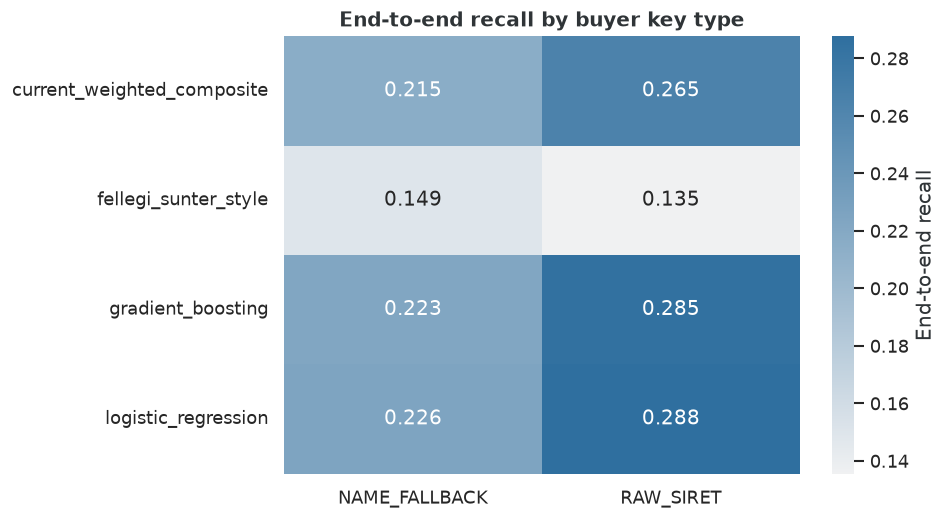

In [14]:
buyer_heatmap = recall_slices.loc[recall_slices["slice"].eq("buyer_key_type")].pivot(
    index="algorithm", columns="slice_value", values="recall_end_to_end"
)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(
    buyer_heatmap,
    annot=True,
    fmt=".3f",
    cmap=sns.light_palette("#2f6f9f", as_cmap=True),
    cbar_kws={"label": "End-to-end recall"},
    ax=ax,
)
ax.set_title("End-to-end recall by buyer key type")
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "recall_by_buyer_key_type_heatmap.png", bbox_inches="tight")
plt.show()

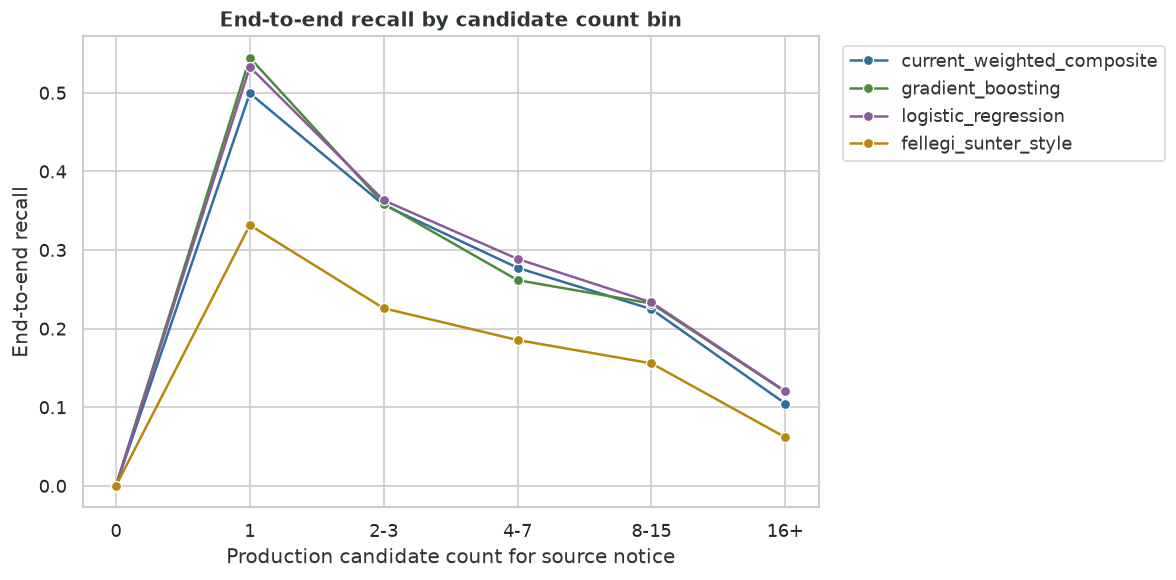

In [15]:
count_slice = recall_slices.loc[
    recall_slices["slice"].eq("candidate_count_bin")
    & recall_slices["slice_value"].isin(["0", "1", "2-3", "4-7", "8-15", "16+"])
].copy()
order = ["0", "1", "2-3", "4-7", "8-15", "16+"]
count_slice["slice_value"] = pd.Categorical(count_slice["slice_value"], order, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=count_slice.sort_values("slice_value"),
    x="slice_value",
    y="recall_end_to_end",
    hue="algorithm",
    marker="o",
    palette=palette,
    ax=ax,
)
ax.set_title("End-to-end recall by candidate count bin")
ax.set_xlabel("Production candidate count for source notice")
ax.set_ylabel("End-to-end recall")
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "recall_by_candidate_count_bin.png", bbox_inches="tight")
plt.show()

In [16]:
bias_summary = (
    recall_slices.loc[
        recall_slices["slice"].isin(["buyer_key_type", "candidate_count_bin", "schema_family"])
        & recall_slices["n_truth"].ge(20)
    ]
    .groupby(["algorithm", "slice"], as_index=False)
    .agg(
        min_recall=("recall_end_to_end", "min"),
        max_recall=("recall_end_to_end", "max"),
        recall_gap=("recall_end_to_end", lambda s: s.max() - s.min()),
        min_n_truth=("n_truth", "min"),
    )
    .sort_values(["slice", "recall_gap"], ascending=[True, False])
)
bias_summary.to_csv(OUTPUT_DIR / "bias_gap_summary.csv", index=False)
bias_summary.style.format({
    "min_recall": "{:.3f}",
    "max_recall": "{:.3f}",
    "recall_gap": "{:.3f}",
})

,algorithm,slice,min_recall,max_recall,recall_gap,min_n_truth
9,logistic_regression,buyer_key_type,0.226,0.288,0.062,6283
6,gradient_boosting,buyer_key_type,0.223,0.285,0.062,6283
0,current_weighted_composite,buyer_key_type,0.215,0.265,0.049,6283
3,fellegi_sunter_style,buyer_key_type,0.135,0.149,0.014,6283
7,gradient_boosting,candidate_count_bin,0.000,0.544,0.544,3481
10,logistic_regression,candidate_count_bin,0.000,0.533,0.533,3481
1,current_weighted_composite,candidate_count_bin,0.000,0.499,0.499,3481
4,fellegi_sunter_style,candidate_count_bin,0.000,0.332,0.332,3481
8,gradient_boosting,schema_family,0.231,0.306,0.075,1907
2,current_weighted_composite,schema_family,0.221,0.281,0.059,1907


## Takeaways

In [17]:
top_two = summary_metrics.sort_values("pair_f1_end_to_end", ascending=False).head(2)
largest_gap = bias_summary.sort_values("recall_gap", ascending=False).iloc[0]
threshold_text = ", ".join(
    f"{row.algorithm}={row.threshold:.4g}" for row in threshold_table.itertuples()
)
display(
    Markdown(
        f'''
        1. The best held-out algorithm by end-to-end pair-F1 is **{top_two.iloc[0]['algorithm']}**
           ({top_two.iloc[0]['pair_f1_end_to_end']:.3f}); the runner-up is
           **{top_two.iloc[1]['algorithm']}** ({top_two.iloc[1]['pair_f1_end_to_end']:.3f}).
        2. The fixed-candidate versus end-to-end gap is substantial because candidate generation
           misses some true links before scoring begins. Use the fixed-candidate view to compare
           scoring models, and the end-to-end view to judge the whole linkage stack.
        3. Largest inspected recall disparity is **{largest_gap['recall_gap']:.3f}** for
           **{largest_gap['algorithm']}** on the **{largest_gap['slice']}** slice. This is the
           first place to look for mechanical bias before using a model for survival analysis.
        4. Thresholds used in this executed run: {threshold_text}.

        Output tables are written to `{OUTPUT_DIR.relative_to(PROJECT_ROOT)}` and figures to
        `{FIGURE_DIR.relative_to(PROJECT_ROOT)}`.
        '''
    )
)


        1. The best held-out algorithm by end-to-end pair-F1 is **gradient_boosting**
           (0.354); the runner-up is
           **logistic_regression** (0.280).
        2. The fixed-candidate versus end-to-end gap is substantial because candidate generation
           misses some true links before scoring begins. Use the fixed-candidate view to compare
           scoring models, and the end-to-end view to judge the whole linkage stack.
        3. Largest inspected recall disparity is **0.544** for
           **gradient_boosting** on the **candidate_count_bin** slice. This is the
           first place to look for mechanical bias before using a model for survival analysis.
        4. Thresholds used in this executed run: current_weighted_composite=0.3432, fellegi_sunter_style=0, logistic_regression=0.7457, gradient_boosting=0.231.

        Output tables are written to `reports/tables/synthetic_benchmark/v0_4_population_alias_revision/linkage_algorithm_benchmark` and figures to
        `reports/figures/synthetic_benchmark/v0_4_population_alias_revision/linkage_algorithm_benchmark`.
        